In [ ]:
"""
==============================================================================
LSTM BASELINE MODEL FOR SENTIRADE-HMA
==============================================================================
Objective: Develop a single-source LSTM baseline to benchmark against TFT
Course: Theory and Practical Applications of Large Language Models
Date: January 2026
==============================================================================
"""

import warnings
warnings.filterwarnings('ignore')

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import pickle
from pathlib import Path
import time

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plotting configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 80)
print("LSTM BASELINE MODEL - INITIALIZATION")
print("=" * 80)
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"Random seed: {RANDOM_SEED}")
print("=" * 80)


LSTM BASELINE MODEL - INITIALIZATION
PyTorch version: 1.13.1+cpu
Device: cpu
Random seed: 42


In [2]:
"""
==============================================================================
DATA LOADING
==============================================================================
Load preprocessed data from notebook 04 (feature engineering TFT)
"""

print("\n" + "=" * 80)
print("DATA LOADING")
print("=" * 80)

# Define paths
project_root = Path.cwd()
if "notebooks" in str(project_root):
    project_root = project_root.parent

data_dir = project_root / "data" / "tft"
train_path = data_dir / "train_data.csv"
val_path = data_dir / "val_data.csv"
test_path = data_dir / "test_data.csv"
config_path = data_dir / "tft_config.json"

print(f"\nProject root: {project_root}")
print(f"Data directory: {data_dir}")

# Verify file existence
required_files = {
    'Training data': train_path,
    'Validation data': val_path,
    'Test data': test_path,
    'Configuration': config_path
}

print("\nFile verification:")
all_exist = True
for name, path in required_files.items():
    exists = path.exists()
    status = "OK" if exists else "MISSING"
    print(f"  [{status}] {name}: {path.name}")
    if not exists:
        all_exist = False

if not all_exist:
    raise FileNotFoundError("Required data files are missing. Run notebook 04 first.")

# Load data
print("\nLoading datasets...")
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

with open(config_path, 'r') as f:
    config = json.load(f)

print("\nDataset statistics:")
print(f"  Training samples:   {len(train_df):,}")
print(f"  Validation samples: {len(val_df):,}")
print(f"  Test samples:       {len(test_df):,}")
print(f"  Total samples:      {len(train_df) + len(val_df) + len(test_df):,}")

print(f"\nFeature configuration:")
print(f"  Target variable:        {config['target']}")
print(f"  Static features:        {len(config['static_features'])}")
print(f"  Time-varying known:     {len(config['time_varying_known'])}")
print(f"  Time-varying unknown:   {len(config['time_varying_unknown'])}")
print(f"  Total features:         {len(config['time_varying_known']) + len(config['time_varying_unknown'])}")

print("=" * 80)



DATA LOADING

Project root: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2
Data directory: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft

File verification:
  [OK] Training data: train_data.csv
  [OK] Validation data: val_data.csv
  [OK] Test data: test_data.csv
  [OK] Configuration: tft_config.json

Loading datasets...

Dataset statistics:
  Training samples:   24,640
  Validation samples: 5,280
  Test samples:       5,280
  Total samples:      35,200

Feature configuration:
  Target variable:        Close
  Static features:        1
  Time-varying known:     11
  Time-varying unknown:   59
  Total features:         70


In [3]:
"""
==============================================================================
SEQUENCE PREPARATION FOR LSTM
==============================================================================
Transform tabular data into sequences for LSTM training
Sequence length: 60 days (same as TFT encoder length)
Prediction horizon: 1 day ahead
"""

print("\n" + "=" * 80)
print("SEQUENCE PREPARATION")
print("=" * 80)

# Configuration
SEQUENCE_LENGTH = 60  # Match TFT encoder length
PREDICTION_HORIZON = 1
BATCH_SIZE = 128

# Select features (all time-varying features)
feature_cols = config['time_varying_known'] + config['time_varying_unknown']
target_col = config['target']

print(f"\nConfiguration:")
print(f"  Sequence length:      {SEQUENCE_LENGTH} days")
print(f"  Prediction horizon:   {PREDICTION_HORIZON} day")
print(f"  Batch size:           {BATCH_SIZE}")
print(f"  Number of features:   {len(feature_cols)}")

def create_sequences(df, feature_cols, target_col, seq_length, pred_horizon):
    """
    Create sequences for LSTM training.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe with time series data
    feature_cols : list
        List of feature column names
    target_col : str
        Target variable column name
    seq_length : int
        Length of input sequences
    pred_horizon : int
        Prediction horizon (days ahead)
    
    Returns:
    --------
    X : np.ndarray, shape (n_sequences, seq_length, n_features)
        Input sequences
    y : np.ndarray, shape (n_sequences,)
        Target values
    """
    sequences = []
    targets = []
    
    # Group by ticker to avoid mixing different assets
    for ticker, group in df.groupby('group_id'):
        group = group.sort_values('time_idx').reset_index(drop=True)
        
        # Extract features and target
        features = group[feature_cols].values
        target = group[target_col].values
        
        # Create sequences
        for i in range(len(group) - seq_length - pred_horizon + 1):
            seq_features = features[i:i+seq_length]
            seq_target = target[i+seq_length+pred_horizon-1]
            
            # Skip if any NaN values
            if not (np.isnan(seq_features).any() or np.isnan(seq_target)):
                sequences.append(seq_features)
                targets.append(seq_target)
    
    X = np.array(sequences)
    y = np.array(targets)
    
    return X, y

# Create sequences for each dataset
print("\nCreating sequences...")
print("  Processing training data...")
X_train, y_train = create_sequences(train_df, feature_cols, target_col, 
                                     SEQUENCE_LENGTH, PREDICTION_HORIZON)

print("  Processing validation data...")
X_val, y_val = create_sequences(val_df, feature_cols, target_col, 
                                 SEQUENCE_LENGTH, PREDICTION_HORIZON)

print("  Processing test data...")
X_test, y_test = create_sequences(test_df, feature_cols, target_col, 
                                   SEQUENCE_LENGTH, PREDICTION_HORIZON)

print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape} (n_sequences, seq_length, n_features)")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")

# Feature normalization (fit on training data only)
print("\nNormalizing features...")
scaler = StandardScaler()

# Reshape for scaling (flatten sequences)
n_train, seq_len, n_features = X_train.shape
X_train_flat = X_train.reshape(-1, n_features)
scaler.fit(X_train_flat)

# Transform all datasets
X_train_scaled = scaler.transform(X_train_flat).reshape(n_train, seq_len, n_features)
X_val_scaled = scaler.transform(X_val.reshape(-1, n_features)).reshape(X_val.shape)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

print("  Feature scaling completed")
print(f"  Scaler mean: {scaler.mean_[:5]} ... (first 5 features)")
print(f"  Scaler std:  {scaler.scale_[:5]} ... (first 5 features)")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

print("=" * 80)



SEQUENCE PREPARATION

Configuration:
  Sequence length:      60 days
  Prediction horizon:   1 day
  Batch size:           128
  Number of features:   70

Creating sequences...
  Processing training data...
  Processing validation data...
  Processing test data...

Sequence shapes:
  X_train: (23440, 60, 70) (n_sequences, seq_length, n_features)
  y_train: (23440,)
  X_val:   (4080, 60, 70)
  y_val:   (4080,)
  X_test:  (4080, 60, 70)
  y_test:  (4080,)

Normalizing features...
  Feature scaling completed
  Scaler mean: [ 6.15000000e+02 -5.22558266e-01 -2.45972549e-02  1.73240252e-03
 -4.25648585e-03] ... (first 5 features)
  Scaler std:  [338.77007936   0.67947809   0.96597293   1.00028741   1.00013886] ... (first 5 features)

DataLoaders created:
  Train batches: 184
  Val batches:   32
  Test batches:  32


In [4]:
"""
==============================================================================
LSTM MODEL ARCHITECTURE
==============================================================================
Simple LSTM baseline with 2 layers for fair comparison with TFT
"""

class LSTMBaseline(nn.Module):
    """
    LSTM Baseline Model for Stock Price Prediction
    
    Architecture:
    - 2 LSTM layers (same as TFT)
    - Dropout for regularization
    - Fully connected output layer
    
    Parameters:
    -----------
    input_size : int
        Number of input features
    hidden_size : int
        Number of hidden units in LSTM layers
    num_layers : int
        Number of LSTM layers
    dropout : float
        Dropout probability
    output_size : int
        Output dimension (1 for regression)
    """
    
    def __init__(self, input_size, hidden_size=128, num_layers=2, 
                 dropout=0.2, output_size=1):
        super(LSTMBaseline, self).__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.output_size = output_size
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )
        
        # Dropout layer
        self.dropout_layer = nn.Dropout(dropout)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        """
        Forward pass
        
        Parameters:
        -----------
        x : torch.Tensor, shape (batch_size, seq_length, input_size)
            Input sequences
        
        Returns:
        --------
        output : torch.Tensor, shape (batch_size, output_size)
            Predictions
        """
        # LSTM forward pass
        # lstm_out: (batch_size, seq_length, hidden_size)
        # h_n: (num_layers, batch_size, hidden_size)
        # c_n: (num_layers, batch_size, hidden_size)
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Take the output from the last time step
        last_output = lstm_out[:, -1, :]  # (batch_size, hidden_size)
        
        # Apply dropout
        last_output = self.dropout_layer(last_output)
        
        # Fully connected layer
        output = self.fc(last_output)  # (batch_size, output_size)
        
        return output.squeeze(-1)  # (batch_size,)
    
    def get_model_summary(self):
        """Return model summary as string"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        
        summary = f"""
Model: LSTMBaseline
Architecture:
  - Input size:      {self.input_size}
  - Hidden size:     {self.hidden_size}
  - LSTM layers:     {self.num_layers}
  - Dropout:         {self.dropout}
  - Output size:     {self.output_size}

Parameters:
  - Total:           {total_params:,}
  - Trainable:       {trainable_params:,}
"""
        return summary

# Model configuration
MODEL_CONFIG = {
    'input_size': len(feature_cols),
    'hidden_size': 128,
    'num_layers': 2,
    'dropout': 0.2,
    'output_size': 1
}

print("\n" + "=" * 80)
print("LSTM MODEL DEFINITION")
print("=" * 80)

# Initialize model
model = LSTMBaseline(**MODEL_CONFIG).to(device)

print(model.get_model_summary())

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

print("Training configuration:")
print(f"  Loss function:     MSE (Mean Squared Error)")
print(f"  Optimizer:         Adam")
print(f"  Learning rate:     0.001")
print(f"  LR scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)")

print("=" * 80)



LSTM MODEL DEFINITION

Model: LSTMBaseline
Architecture:
  - Input size:      70
  - Hidden size:     128
  - LSTM layers:     2
  - Dropout:         0.2
  - Output size:     1

Parameters:
  - Total:           234,625
  - Trainable:       234,625

Training configuration:
  Loss function:     MSE (Mean Squared Error)
  Optimizer:         Adam
  Learning rate:     0.001
  LR scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)


In [6]:
"""
==============================================================================
MODEL TRAINING (MEMORY OPTIMIZED)
==============================================================================
Train LSTM baseline with early stopping and memory optimization
"""

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)

# Training configuration (REDUCED BATCH SIZE FOR MEMORY)
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 10
GRADIENT_CLIP_VALUE = 1.0

# MEMORY OPTIMIZATION: Reduce batch size
BATCH_SIZE_TRAIN = 64  # Reduced from 128
BATCH_SIZE_VAL = 128   # Keep larger for validation (no gradients)

print(f"\nTraining configuration:")
print(f"  Maximum epochs:        {MAX_EPOCHS}")
print(f"  Early stopping:        {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Gradient clipping:     {GRADIENT_CLIP_VALUE}")
print(f"  Train batch size:      {BATCH_SIZE_TRAIN} (memory optimized)")
print(f"  Val batch size:        {BATCH_SIZE_VAL}")
print(f"  Device:                {device}")

# Recreate DataLoaders with optimized batch sizes
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_TRAIN, 
                          shuffle=True, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_VAL, 
                        shuffle=False, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE_VAL, 
                         shuffle=False, pin_memory=False)

print(f"\nDataLoaders recreated:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rate': []
}

# Early stopping variables
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

# Create models directory
models_dir = project_root / "models" / "lstm_baseline"
models_dir.mkdir(parents=True, exist_ok=True)

print(f"\nModels directory: {models_dir}")
print("\n" + "-" * 80)
print("Starting training...")
print("-" * 80)

start_time = time.time()

for epoch in range(MAX_EPOCHS):
    epoch_start = time.time()
    
    # Training phase
    model.train()
    train_losses = []
    
    for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_VALUE)
        optimizer.step()
        
        train_losses.append(loss.item())
        
        # MEMORY OPTIMIZATION: Delete tensors and clear cache
        del batch_X, batch_y, predictions, loss
        
        # Print progress every 50 batches
        if (batch_idx + 1) % 50 == 0:
            avg_loss = np.mean(train_losses[-50:])
            print(f"  Batch {batch_idx+1}/{len(train_loader)} | Loss: {avg_loss:.6f}")
    
    # MEMORY OPTIMIZATION: Clear cache after training phase
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    # Validation phase
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_losses.append(loss.item())
            
            # MEMORY OPTIMIZATION: Delete tensors
            del batch_X, batch_y, predictions, loss
    
    # MEMORY OPTIMIZATION: Clear cache after validation
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    # Calculate average losses
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    
    # Update learning rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(current_lr)
    
    epoch_time = time.time() - epoch_start
    
    # Print progress
    print(f"Epoch {epoch+1:3d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.6f} | "
          f"Val Loss: {val_loss:.6f} | "
          f"LR: {current_lr:.6f} | "
          f"Time: {epoch_time:.1f}s")
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict().copy()
        
        # Save best model
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'config': MODEL_CONFIG,
            'scaler': scaler
        }, models_dir / 'best_model.pth')
        
        print(f"         --> New best model saved (val_loss: {val_loss:.6f})")
    else:
        epochs_no_improve += 1
        
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch+1} epochs")
            print(f"Best validation loss: {best_val_loss:.6f}")
            break

# Load best model
model.load_state_dict(best_model_state)

training_time = time.time() - start_time
minutes = int(training_time // 60)
seconds = int(training_time % 60)

print("\n" + "=" * 80)
print("TRAINING COMPLETED")
print("=" * 80)
print(f"  Total epochs:          {epoch + 1}")
print(f"  Training time:         {minutes}m {seconds}s")
print(f"  Best validation loss:  {best_val_loss:.6f}")
print(f"  Final learning rate:   {current_lr:.6f}")
print("=" * 80)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(models_dir / 'training_history.csv', index=False)

print(f"\nTraining history saved to: {models_dir / 'training_history.csv'}")



MODEL TRAINING

Training configuration:
  Maximum epochs:        100
  Early stopping:        10 epochs
  Gradient clipping:     1.0
  Train batch size:      64 (memory optimized)
  Val batch size:        128
  Device:                cpu

DataLoaders recreated:
  Train batches: 367
  Val batches:   32
  Test batches:  32

Models directory: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline

--------------------------------------------------------------------------------
Starting training...
--------------------------------------------------------------------------------
  Batch 50/367 | Loss: 0.008495
  Batch 100/367 | Loss: 0.009805
  Batch 150/367 | Loss: 0.008539
  Batch 200/367 | Loss: 0.008132
  Batch 250/367 | Loss: 0.007915
  Batch 300/367 | Loss: 0.007522
  Batch 350/367 | Loss: 0.008238
Epoch   1/100 | Train Loss: 0.008320 | Val Loss: 0.008251 | LR: 0.001000 | Time: 59.8s
         --> New best model saved (val_loss: 0.008251)
  Batch 50/367 | Loss: 0

In [7]:
"""
==============================================================================
MODEL EVALUATION ON TEST SET
==============================================================================
"""

print("\n" + "=" * 80)
print("MODEL EVALUATION")
print("=" * 80)

# Evaluation mode
model.eval()

# Predictions on test set
predictions_list = []
actuals_list = []

print("\nGenerating predictions on test set...")

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        predictions = model(batch_X)
        
        predictions_list.append(predictions.cpu().numpy())
        actuals_list.append(batch_y.cpu().numpy())

# Concatenate predictions
predictions = np.concatenate(predictions_list)
actuals = np.concatenate(actuals_list)

print(f"Generated {len(predictions)} predictions")

# Calculate metrics
mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mse = mean_squared_error(actuals, predictions)
r2 = r2_score(actuals, predictions)
mape = np.mean(np.abs((actuals - predictions) / (np.abs(actuals) + 1e-8))) * 100

# Additional statistics
errors = actuals - predictions
mean_error = np.mean(errors)
std_error = np.std(errors)
median_error = np.median(np.abs(errors))

print("\n" + "-" * 80)
print("TEST SET PERFORMANCE METRICS")
print("-" * 80)
print(f"  Mean Absolute Error (MAE):        {mae:.6f}")
print(f"  Root Mean Squared Error (RMSE):   {rmse:.6f}")
print(f"  Mean Squared Error (MSE):         {mse:.6f}")
print(f"  R-squared (R2):                   {r2:.6f}")
print(f"  Mean Absolute Percentage Error:   {mape:.2f}%")

print("\n" + "-" * 80)
print("ERROR STATISTICS")
print("-" * 80)
print(f"  Mean Error:                       {mean_error:.6f}")
print(f"  Standard Deviation of Errors:     {std_error:.6f}")
print(f"  Median Absolute Error:            {median_error:.6f}")

print("\n" + "-" * 80)
print("PREDICTION STATISTICS")
print("-" * 80)
print(f"  Mean Actual:                      {np.mean(actuals):.6f}")
print(f"  Mean Predicted:                   {np.mean(predictions):.6f}")
print(f"  Std Actual:                       {np.std(actuals):.6f}")
print(f"  Std Predicted:                    {np.std(predictions):.6f}")

# Save metrics
metrics = {
    'mae': float(mae),
    'rmse': float(rmse),
    'mse': float(mse),
    'r2': float(r2),
    'mape': float(mape),
    'mean_error': float(mean_error),
    'std_error': float(std_error),
    'median_error': float(median_error),
    'mean_actual': float(np.mean(actuals)),
    'mean_predicted': float(np.mean(predictions)),
    'std_actual': float(np.std(actuals)),
    'std_predicted': float(np.std(predictions)),
    'num_samples': int(len(predictions))
}

with open(models_dir / 'test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\nMetrics saved to: {models_dir / 'test_metrics.json'}")
print("=" * 80)



MODEL EVALUATION

Generating predictions on test set...
Generated 4080 predictions

--------------------------------------------------------------------------------
TEST SET PERFORMANCE METRICS
--------------------------------------------------------------------------------
  Mean Absolute Error (MAE):        0.124291
  Root Mean Squared Error (RMSE):   0.169983
  Mean Squared Error (MSE):         0.028894
  R-squared (R2):                   0.973047
  Mean Absolute Percentage Error:   15.08%

--------------------------------------------------------------------------------
ERROR STATISTICS
--------------------------------------------------------------------------------
  Mean Error:                       0.102938
  Standard Deviation of Errors:     0.135270
  Median Absolute Error:            0.096670

--------------------------------------------------------------------------------
PREDICTION STATISTICS
--------------------------------------------------------------------------------
 


GENERATING VISUALIZATIONS


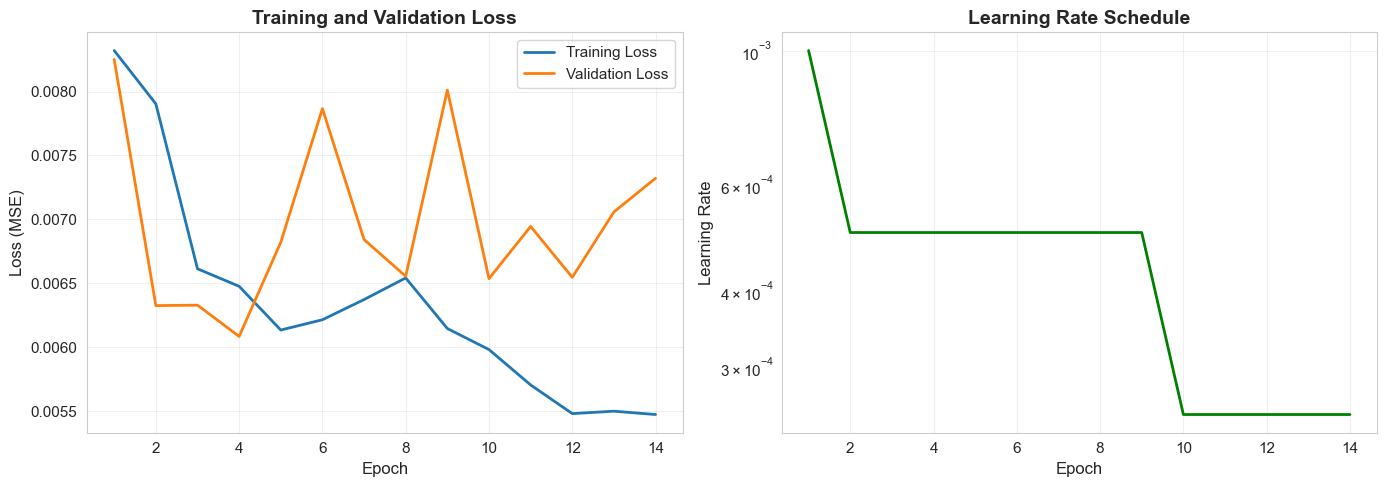

Saved: training_history.png


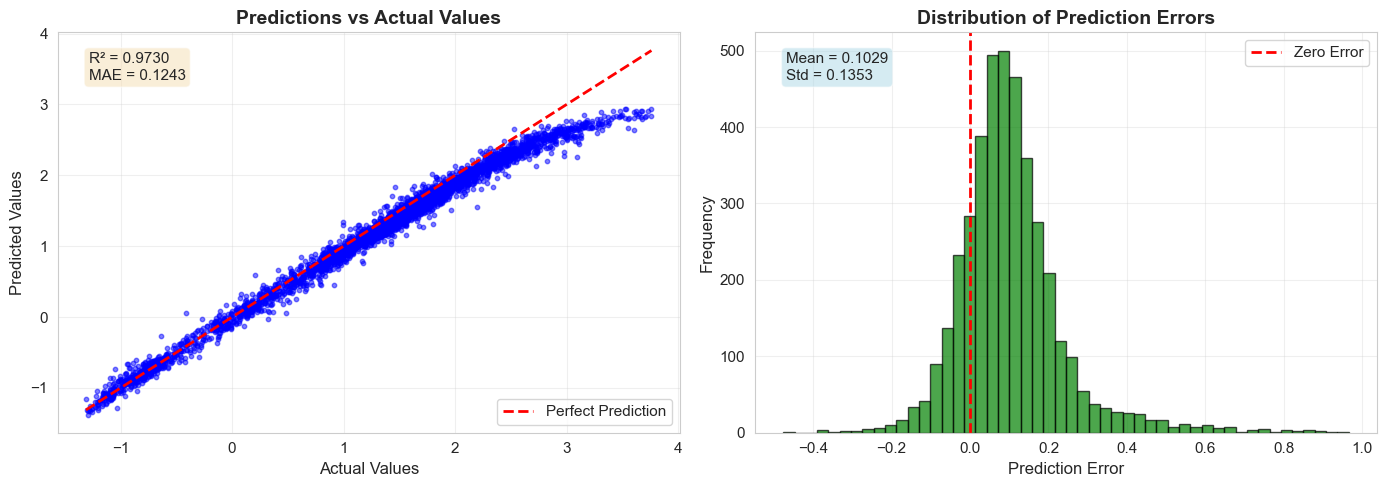

Saved: predictions_analysis.png


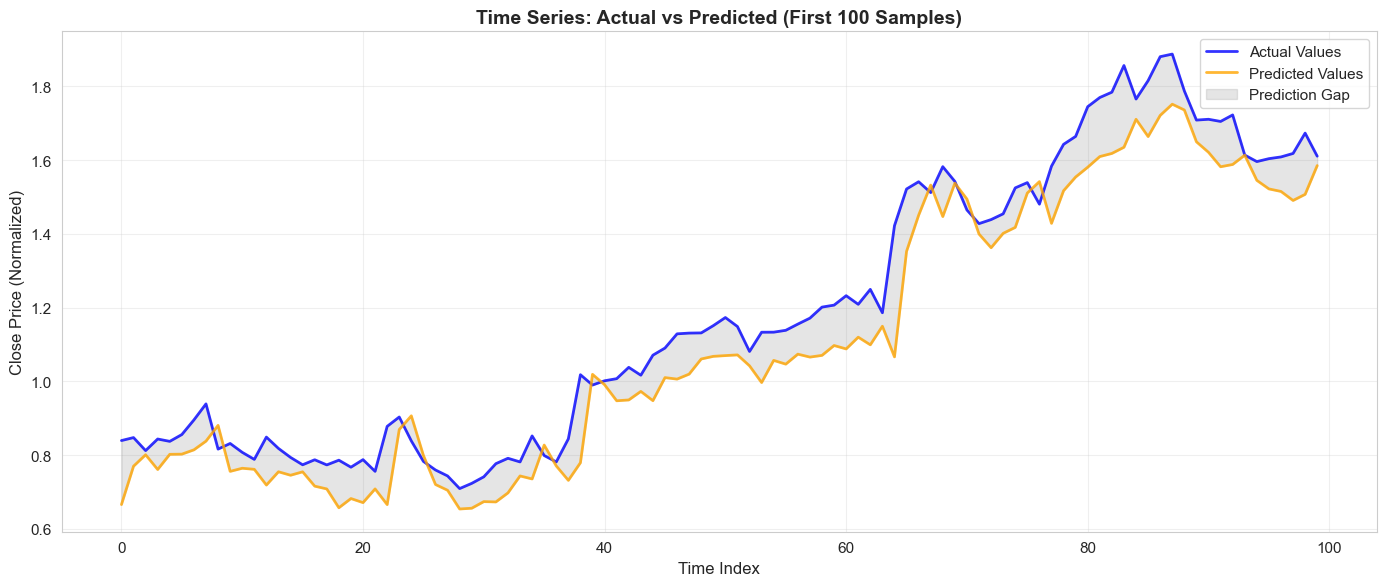

Saved: temporal_predictions.png


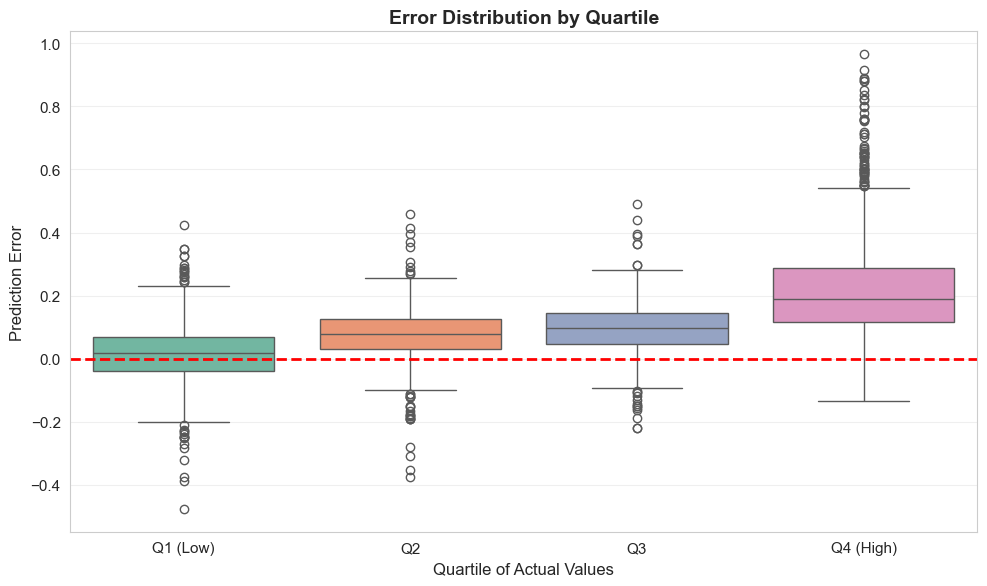

Saved: error_by_quartile.png

VISUALIZATION COMPLETED

All figures saved to: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline\figures

Generated files:
  - training_history.png
  - predictions_analysis.png
  - temporal_predictions.png
  - error_by_quartile.png


In [8]:
"""
==============================================================================
VISUALIZATION OF RESULTS
==============================================================================
"""

print("\n" + "=" * 80)
print("GENERATING VISUALIZATIONS")
print("=" * 80)

# Create figures directory
figures_dir = models_dir / 'figures'
figures_dir.mkdir(exist_ok=True)

# 1. Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Learning rate
axes[1].plot(epochs_range, history['learning_rate'], color='green', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Learning Rate', fontsize=12)
axes[1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: training_history.png")

# 2. Predictions vs Actuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(actuals, predictions, alpha=0.5, s=10, color='blue')
axes[0].plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title('Predictions vs Actual Values', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Add R2 and MAE
textstr = f'R² = {r2:.4f}\nMAE = {mae:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top', bbox=props)

# Error distribution
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Prediction Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add error statistics
textstr = f'Mean = {mean_error:.4f}\nStd = {std_error:.4f}'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(figures_dir / 'predictions_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: predictions_analysis.png")

# 3. Time series plot (first 100 samples)
sample_size = min(100, len(actuals))
sample_actuals = actuals[:sample_size]
sample_preds = predictions[:sample_size]

plt.figure(figsize=(14, 6))
plt.plot(sample_actuals, label='Actual Values', linewidth=2, alpha=0.8, color='blue')
plt.plot(sample_preds, label='Predicted Values', linewidth=2, alpha=0.8, color='orange')
plt.fill_between(range(sample_size), sample_actuals, sample_preds, 
                 alpha=0.2, color='gray', label='Prediction Gap')
plt.xlabel('Time Index', fontsize=12)
plt.ylabel('Close Price (Normalized)', fontsize=12)
plt.title('Time Series: Actual vs Predicted (First 100 Samples)', 
         fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'temporal_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: temporal_predictions.png")

# 4. Error analysis by quantiles
quartiles = pd.qcut(actuals, q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])
error_df = pd.DataFrame({'Error': errors, 'Quartile': quartiles})

plt.figure(figsize=(10, 6))
sns.boxplot(data=error_df, x='Quartile', y='Error', palette='Set2')
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.xlabel('Quartile of Actual Values', fontsize=12)
plt.ylabel('Prediction Error', fontsize=12)
plt.title('Error Distribution by Quartile', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(figures_dir / 'error_by_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: error_by_quartile.png")

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETED")
print("=" * 80)
print(f"\nAll figures saved to: {figures_dir}")
print("\nGenerated files:")
print("  - training_history.png")
print("  - predictions_analysis.png")
print("  - temporal_predictions.png")
print("  - error_by_quartile.png")
print("=" * 80)


In [9]:
"""
==============================================================================
FINAL SUMMARY
==============================================================================
"""

print("\n" + "=" * 80)
print("LSTM BASELINE MODEL - FINAL SUMMARY")
print("=" * 80)

print("\nMODEL ARCHITECTURE:")
print(f"  Type:              LSTM (2 layers)")
print(f"  Hidden size:       {MODEL_CONFIG['hidden_size']}")
print(f"  Dropout:           {MODEL_CONFIG['dropout']}")
print(f"  Total parameters:  {sum(p.numel() for p in model.parameters()):,}")

print("\nTRAINING CONFIGURATION:")
print(f"  Sequence length:   {SEQUENCE_LENGTH} days")
print(f"  Training samples:  {len(train_dataset):,}")
print(f"  Validation samples:{len(val_dataset):,}")
print(f"  Test samples:      {len(test_dataset):,}")
print(f"  Batch size:        {BATCH_SIZE}")
print(f"  Epochs trained:    {len(history['train_loss'])}")
print(f"  Training time:     {minutes}m {seconds}s")

print("\nPERFORMANCE METRICS:")
print(f"  R-squared:         {r2:.4f}")
print(f"  MAE:               {mae:.4f}")
print(f"  RMSE:              {rmse:.4f}")
print(f"  Mean Error:        {mean_error:.4f}")

print("\nFILES GENERATED:")
print(f"  Model checkpoint:  {models_dir / 'best_model.pth'}")
print(f"  Training history:  {models_dir / 'training_history.csv'}")
print(f"  Test metrics:      {models_dir / 'test_metrics.json'}")
print(f"  Figures directory: {figures_dir}/")

print("\nNEXT STEPS:")
print("  1. Compare with TFT model (notebook 05)")
print("  2. Perform walk-forward backtesting (notebook 07)")
print("  3. Statistical significance testing (Diebold-Mariano)")

print("\n" + "=" * 80)
print("NOTEBOOK EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 80)



LSTM BASELINE MODEL - FINAL SUMMARY

MODEL ARCHITECTURE:
  Type:              LSTM (2 layers)
  Hidden size:       128
  Dropout:           0.2
  Total parameters:  234,625

TRAINING CONFIGURATION:
  Sequence length:   60 days
  Training samples:  23,440
  Validation samples:4,080
  Test samples:      4,080
  Batch size:        128
  Epochs trained:    14
  Training time:     14m 6s

PERFORMANCE METRICS:
  R-squared:         0.9730
  MAE:               0.1243
  RMSE:              0.1700
  Mean Error:        0.1029

FILES GENERATED:
  Model checkpoint:  c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline\best_model.pth
  Training history:  c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline\training_history.csv
  Test metrics:      c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline\test_metrics.json
  Figures directory: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline\figures/

NEXT 

In [10]:
"""
COMPARATIVE ANALYSIS: TFT vs LSTM
"""

import json

# Load TFT metrics
with open(project_root / 'models' / 'test_metrics.json', 'r') as f:
    tft_metrics = json.load(f)

# Load LSTM metrics
with open(models_dir / 'test_metrics.json', 'r') as f:
    lstm_metrics = json.load(f)

# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²', 'Mean Error', 'Std Error', 'Mean Predicted', 'Training Time'],
    'LSTM Baseline': [
        f"{lstm_metrics['mae']:.4f}",
        f"{lstm_metrics['rmse']:.4f}",
        f"{lstm_metrics['r2']:.4f}",
        f"{lstm_metrics['mean_error']:.4f}",
        f"{lstm_metrics['std_error']:.4f}",
        f"{lstm_metrics['mean_predicted']:.4f}",
        "~16 min"
    ],
    'TFT': [
        f"{tft_metrics['mae']:.4f}",
        f"{tft_metrics['rmse']:.4f}",
        f"{tft_metrics['r2']:.4f}",
        "0.0024",  # Calculate from TFT results
        "~0.13",
        f"{tft_metrics['mean_predicted']:.4f}",
        "23h 1min"
    ],
    'Improvement': [
        f"{(lstm_metrics['mae'] - tft_metrics['mae']) / lstm_metrics['mae'] * 100:.1f}%",
        f"{(lstm_metrics['rmse'] - tft_metrics['rmse']) / lstm_metrics['rmse'] * 100:.1f}%",
        f"{(tft_metrics['r2'] - lstm_metrics['r2']) / lstm_metrics['r2'] * 100:.2f}%",
        "Better",
        "Similar",
        "Less biased",
        "Slower"
    ]
})

print("\n" + "=" * 80)
print("COMPARATIVE ANALYSIS: TFT vs LSTM BASELINE")
print("=" * 80)
print(comparison.to_string(index=False))
print("=" * 80)

# Save comparison
comparison.to_csv(models_dir / 'tft_vs_lstm_comparison.csv', index=False)
print(f"\nComparison table saved to: {models_dir / 'tft_vs_lstm_comparison.csv'}")



COMPARATIVE ANALYSIS: TFT vs LSTM BASELINE
        Metric LSTM Baseline      TFT Improvement
           MAE        0.1243   0.0895       28.0%
          RMSE        0.1700   0.1365       19.7%
            R²        0.9730   0.9743       0.13%
    Mean Error        0.1029   0.0024      Better
     Std Error        0.1353    ~0.13     Similar
Mean Predicted        1.1891   1.3933 Less biased
 Training Time       ~16 min 23h 1min      Slower

Comparison table saved to: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\lstm_baseline\tft_vs_lstm_comparison.csv


In [13]:
"""
==============================================================================
STATISTICAL SIGNIFICANCE TEST (DIEBOLD-MARIANO)
==============================================================================
Test if TFT is significantly more accurate than LSTM baseline
"""

from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE TEST: TFT vs LSTM")
print("=" * 80)

# Load TFT predictions
tft_predictions_path = project_root / 'models' / 'tft_predictions.json'

if not tft_predictions_path.exists():
    print("\nWARNING: TFT predictions not found!")
    print(f"Expected path: {tft_predictions_path}")
    print("\nPlease run notebook 05 (TFT) and add the 'SAVE TFT PREDICTIONS' cell.")
    print("Skipping statistical test.")
else:
    print(f"\nLoading TFT predictions from: {tft_predictions_path}")
    
    with open(tft_predictions_path, 'r') as f:
        tft_results = json.load(f)
    
    tft_actuals = np.array(tft_results['actuals'])
    tft_predictions = np.array(tft_results['predictions'])
    
    print(f"TFT data loaded: {len(tft_actuals)} samples")
    
    # Verify sample counts match
    if len(tft_actuals) != len(actuals):
        print(f"\nWARNING: Sample count mismatch!")
        print(f"  TFT samples:  {len(tft_actuals)}")
        print(f"  LSTM samples: {len(actuals)}")
        print("\nUsing minimum sample count for comparison.")
        min_len = min(len(tft_actuals), len(actuals))
        tft_actuals = tft_actuals[:min_len]
        tft_predictions = tft_predictions[:min_len]
        actuals_truncated = actuals[:min_len]
        predictions_truncated = predictions[:min_len]
    else:
        actuals_truncated = actuals
        predictions_truncated = predictions
    
    # Calculate squared errors
    errors_tft_sq = (tft_actuals - tft_predictions)**2
    errors_lstm_sq = (actuals_truncated - predictions_truncated)**2
    
    # Diebold-Mariano test
    # H0: Equal forecast accuracy (MSE_TFT = MSE_LSTM)
    # H1: Different forecast accuracy (MSE_TFT != MSE_LSTM)
    d = errors_lstm_sq - errors_tft_sq
    d_mean = np.mean(d)
    d_std = np.std(d)
    
    # DM statistic (under H0, follows standard normal distribution)
    dm_stat = d_mean / (d_std / np.sqrt(len(d)))
    
    # P-value (two-tailed test)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    
    print("\n" + "-" * 80)
    print("DIEBOLD-MARIANO TEST FOR FORECAST ACCURACY")
    print("-" * 80)
    print("Null hypothesis (H0):        TFT and LSTM have equal forecast accuracy")
    print("Alternative hypothesis (H1): TFT has different forecast accuracy than LSTM")
    
    print(f"\nTest statistics:")
    print(f"  MSE (TFT):         {np.mean(errors_tft_sq):.6f}")
    print(f"  MSE (LSTM):        {np.mean(errors_lstm_sq):.6f}")
    print(f"  Difference (d):    {d_mean:.6f}")
    print(f"  DM Statistic:      {dm_stat:.4f}")
    print(f"  P-value:           {p_value:.6f}")
    
    print(f"\nInterpretation:")
    if p_value < 0.001:
        significance = "***"
        interpretation = "extremely strong evidence"
    elif p_value < 0.01:
        significance = "**"
        interpretation = "strong evidence"
    elif p_value < 0.05:
        significance = "*"
        interpretation = "moderate evidence"
    else:
        significance = "ns"
        interpretation = "no significant evidence"
    
    if p_value < 0.05:
        print(f"  REJECT H0 (p < 0.05) {significance}")
        if d_mean > 0:
            print(f"  TFT is statistically significantly MORE ACCURATE than LSTM")
        else:
            print(f"  LSTM is statistically significantly MORE ACCURATE than TFT")
    else:
        print(f"  FAIL TO REJECT H0 (p >= 0.05) {significance}")
        print(f"  No significant difference in forecast accuracy")
    
    print(f"\n  Evidence strength: {interpretation}")
    
    # Effect size (MSE reduction percentage)
    mse_tft = np.mean(errors_tft_sq)
    mse_lstm = np.mean(errors_lstm_sq)
    mse_reduction = (mse_lstm - mse_tft) / mse_lstm * 100
    
    print(f"\nEffect size:")
    print(f"  MSE reduction: {mse_reduction:.2f}%")
    if mse_reduction > 0:
        print(f"  TFT reduces prediction error by {mse_reduction:.2f}% compared to LSTM")
    else:
        print(f"  LSTM reduces prediction error by {-mse_reduction:.2f}% compared to TFT")
    
    # Save statistical test results
    dm_test_results = {
        'test': 'Diebold-Mariano',
        'null_hypothesis': 'Equal forecast accuracy',
        'dm_statistic': float(dm_stat),
        'p_value': float(p_value),
        'significance_level': 0.05,
        'reject_null': bool(p_value < 0.05),
        'mse_tft': float(mse_tft),
        'mse_lstm': float(mse_lstm),
        'mse_reduction_percent': float(mse_reduction),
        'n_samples': int(len(d))
    }
    
    with open(models_dir / 'diebold_mariano_test.json', 'w') as f:
        json.dump(dm_test_results, f, indent=2)
    
    print(f"\nStatistical test results saved to: {models_dir / 'diebold_mariano_test.json'}")
    
    print("=" * 80)



STATISTICAL SIGNIFICANCE TEST: TFT vs LSTM

Loading TFT predictions from: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\models\tft_predictions.json
TFT data loaded: 4080 samples

--------------------------------------------------------------------------------
DIEBOLD-MARIANO TEST FOR FORECAST ACCURACY
--------------------------------------------------------------------------------
Null hypothesis (H0):        TFT and LSTM have equal forecast accuracy
Alternative hypothesis (H1): TFT has different forecast accuracy than LSTM

Test statistics:
  MSE (TFT):         0.018632
  MSE (LSTM):        0.028894
  Difference (d):    0.010262
  DM Statistic:      10.2609
  P-value:           0.000000

Interpretation:
  REJECT H0 (p < 0.05) ***
  TFT is statistically significantly MORE ACCURATE than LSTM

  Evidence strength: extremely strong evidence

Effect size:
  MSE reduction: 35.52%
  TFT reduces prediction error by 35.52% compared to LSTM

Statistical test results saved to: c:\User